<a href="https://colab.research.google.com/github/khushikayy/sklearn_library/blob/main/Sklearn(3)_StandardScaler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np #linear algebra
import pandas as pd #data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [ ]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
df.shape

(400, 5)

In [ ]:
df.drop('User ID',axis=1,inplace=True)

In [ ]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [ ]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

In [ ]:
df

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0
...,...,...,...,...
395,0,46,41000,1
396,1,51,23000,1
397,0,50,20000,1
398,1,36,33000,0


##Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Purchased',axis=1)
y = df['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,Gender,Age,EstimatedSalary
3,0,27,57000
18,1,46,28000
202,0,39,134000
250,0,44,39000
274,0,57,26000
...,...,...,...
71,0,24,27000
106,0,26,35000
270,0,43,133000
348,1,39,77000


##Applying StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-1.        , -1.06675246, -0.38634438],
       [ 1.        ,  0.79753468, -1.22993871],
       [-1.        ,  0.11069205,  1.853544  ],
       [-1.        ,  0.60129393, -0.90995465],
       [-1.        ,  1.87685881, -1.28811763],
       [ 1.        , -0.57615058,  1.44629156],
       [ 1.        ,  0.3069328 , -0.53179168],
       [ 1.        ,  0.99377543,  0.10817643],
       [ 1.        , -1.16487283,  0.45724994],
       [ 1.        , -1.55735433,  0.31180264],
       [ 1.        ,  1.0918958 ,  0.45724994],
       [-1.        , -0.18366908, -0.47361276],
       [ 1.        ,  0.20881242, -0.32816546],
       [-1.        ,  0.3069328 ,  0.28271318],
       [ 1.        , -1.16487283, -1.57901222],
       [-1.        ,  0.11069205,  0.25362372],
       [ 1.        ,  2.07309956,  1.73718616],
       [ 1.        ,  0.40505317, -0.18271817],
       [-1.        ,  1.4843773 ,  2.11534913],
       [ 1.        , -0.37990983,  1.21357589],
       [-1.        ,  1.87685881,  1.504

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled = pd.DataFrame(X_test_scaled)

In [ ]:
X_train

,Gender,Age,EstimatedSalary
3,0,27,57000
18,1,46,28000
202,0,39,134000
250,0,44,39000
274,0,57,26000
...,...,...,...
71,0,24,27000
106,0,26,35000
270,0,43,133000
348,1,39,77000


In [ ]:
X_train_scaled

,0,1,2
0,-1.0,-1.066752,-0.386344
1,1.0,0.797535,-1.229939
2,-1.0,0.110692,1.853544
3,-1.0,0.601294,-0.909955
4,-1.0,1.876859,-1.288118
...,...,...,...
315,-1.0,-1.361114,-1.259028
316,-1.0,-1.164873,-1.026312
317,-1.0,0.503174,1.824455
318,1.0,0.110692,0.195445


In [ ]:
np.round(X_train.describe(),2)

,Gender,Age,EstimatedSalary
count,320.0,320.00,320.00
mean,0.5,37.87,70281.25
std,0.5,10.21,34430.55
min,0.0,18.00,15000.00
25%,0.0,30.00,43000.00
50%,0.5,37.00,71000.00
75%,1.0,45.00,88000.00
max,1.0,60.00,150000.00


In [ ]:
np.round(X_train_scaled.describe(),2)

,0,1,2
count,320.0,320.00,320.00
mean,0.0,-0.00,0.00
std,1.0,1.00,1.00
min,-1.0,-1.95,-1.61
25%,-1.0,-0.77,-0.79
50%,0.0,-0.09,0.02
75%,1.0,0.70,0.52
max,1.0,2.17,2.32


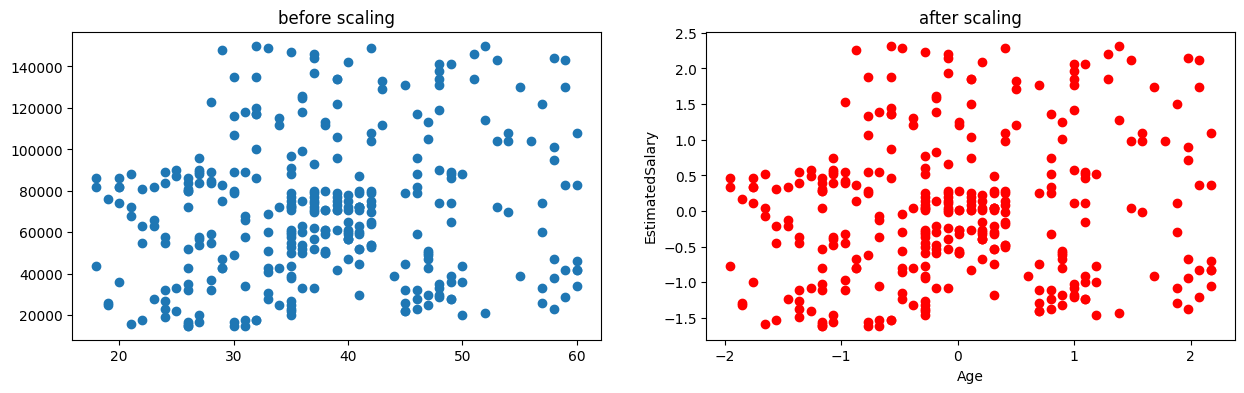

In [ ]:
# to show if StandardScaler affect Data disribution
fig,(x1,x2) = plt.subplots(1,2,figsize=(15,4))

x1.scatter(X_train.iloc[:, 1], X_train.iloc[:, 2])
x1.set_title("before scaling")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")

x2.scatter(X_train_scaled.iloc[:, 1], X_train_scaled.iloc[:, 2],color='red')
x2.set_title("after scaling")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")

plt.show()